In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import ast
import re

In [2]:
# -------------------------------
# FILE PATHS
# -------------------------------
LOD_PATH = "data/Pulvinatal_LOD_per_snp.csv"
QTL_RESULTS_PATH = "results/Pulvinatal_QTL_genes_20260330.csv"
HIP_HITS_PATH = "data/HIP_HITS_v2.tsv"
SNP_INFO_PATH = "data/snp_info_complete.tsv"
PLEIO_PATH = "data/pleiotropic_CI.csv"

# -------------------------------
# PLOTTING STYLE
# -------------------------------
plt.rcParams.update({
    "font.size": 24,
    "font.family": "Nimbus Sans"
})

In [3]:
lod_df = pd.read_csv(LOD_PATH)
interval_df = pd.read_csv(QTL_RESULTS_PATH)
hip_hits = pd.read_csv(HIP_HITS_PATH, sep="\t")
snp_info = pd.read_csv(SNP_INFO_PATH, sep="\t")
pleio_track = pd.read_csv(PLEIO_PATH)

print("lod_df:", lod_df.shape)
print("interval_df:", interval_df.shape)
print("hip_hits:", hip_hits.shape)
print("snp_info:", snp_info.shape)
print("pleio_track:", pleio_track.shape)

lod_df.head()

lod_df: (37339, 7)
interval_df: (127, 9)
hip_hits: (160, 2)
snp_info: (41594, 12)
pleio_track: (12071326, 2)


,SNP,Chromosome,Position (bp),C,H,F,D
0,snp1,1,27210,1.530708,134.600075,124.905667,74.193223
1,snp2,1,27290,1.552951,134.521658,124.752968,74.114626
2,snp3,1,27356,1.543347,134.719018,125.096943,74.437818
3,snp4,1,27357,1.543347,134.719018,125.096943,74.437818
4,snp5,1,27370,1.538815,134.537615,124.909982,74.259026


In [4]:
# Yeast chromosome lengths
chrom_lengths = {
    1: 230218,
    2: 813184,
    3: 316620,
    4: 1531933,
    5: 576874,
    6: 270161,
    7: 1090940,
    8: 562643,
    9: 439888,
    10: 745751,
    11: 666816,
    12: 1078177,
    13: 924431,
    14: 784333,
    15: 1091291,
    16: 948066
}

chrom_offsets = {}
running = 0
for chrom in range(1, 17):
    chrom_offsets[chrom] = running
    running += chrom_lengths[chrom]

def get_abs_pos(chrom, pos):
    return chrom_offsets[int(chrom)] + int(pos)

In [5]:
# Per-SNP LOD table
lod_df["abs_pos"] = [
    get_abs_pos(c, p)
    for c, p in zip(lod_df["Chromosome"], lod_df["Position (bp)"])
]

# Full snp_info table
if "abs_pos" not in snp_info.columns:
    snp_info["abs_pos"] = [
        get_abs_pos(c, p)
        for c, p in zip(snp_info["Chromosome"], snp_info["Position (bp)"])
    ]

# QTL interval table
interval_df["mid"] = ((interval_df["start"] + interval_df["end"]) / 2).round().astype(int)
interval_df["abs_mid"] = [
    get_abs_pos(c, m)
    for c, m in zip(interval_df["chrom"], interval_df["mid"])
]

lod_df.head()

,SNP,Chromosome,Position (bp),C,H,F,D,abs_pos
0,snp1,1,27210,1.530708,134.600075,124.905667,74.193223,27210
1,snp2,1,27290,1.552951,134.521658,124.752968,74.114626,27290
2,snp3,1,27356,1.543347,134.719018,125.096943,74.437818,27356
3,snp4,1,27357,1.543347,134.719018,125.096943,74.437818,27357
4,snp5,1,27370,1.538815,134.537615,124.909982,74.259026,27370


In [6]:
# Attach pleiotropic score to snp_info if possible
if "CI_track" in pleio_track.columns:
    if "abs_pos" in pleio_track.columns:
        pleio_track = pleio_track.set_index("abs_pos")
    snp_info["pleio_score"] = list(pleio_track.loc[snp_info.abs_pos]["CI_track"])
else:
    print("Warning: pleio_track does not contain 'CI_track'")

In [7]:
def make_man(df_plot, ax, value="LOD", bg_color=None, ylab="LOD"):
    df = df_plot.copy().sort_values("abs_pos")

    # Background pleiotropy line if available
    if bg_color is not None and "CI_track" in bg_color.columns:
        bg = bg_color.copy()
        if "abs_pos" in bg.columns:
            bg = bg.sort_values("abs_pos")
            ax.plot(bg["abs_pos"], bg["CI_track"], color="lightgray", linewidth=1.3, zorder=1)

    # Main LOD curve
    ax.plot(df["abs_pos"], df[value], color="gray", linewidth=1.0, zorder=2)

    # Vertical black bars
    ax.vlines(
        df["abs_pos"],
        ymin=0,
        ymax=df[value],
        color="black",
        linewidth=0.7,
        alpha=0.8,
        zorder=3
    )

    # Chromosome boundaries
    for chrom in range(2, 17):
        ax.axvline(chrom_offsets[chrom], color="lightgray", linewidth=1.5, zorder=0)

    # Chromosome ticks
    xticks = []
    xlabels = []
    for chrom in range(1, 17):
        start = chrom_offsets[chrom]
        end = start + chrom_lengths[chrom]
        xticks.append((start + end) / 2)
        xlabels.append(str(chrom))

    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels)
    ax.set_xlim(0, sum(chrom_lengths.values()))
    ax.set_xlabel("Chromosome")
    ax.set_ylabel(ylab)

    return ax

In [8]:
def _prepare_hip_coords(hip_hits_df, snp_info_df, multi_drug_color="red"):
    hip = hip_hits_df.copy()
    hip["gene"] = hip["gene"].astype(str).str.strip()
    hip["name"] = hip["name"].astype(str).str.strip()
    hip = hip.replace("", np.nan).dropna(subset=["gene", "name"])

    gene_records = []
    for gene, sub in snp_info_df.groupby("gene_standard_name", dropna=True):
        if pd.isna(gene):
            continue

        sub = sub.sort_values(["Chromosome", "Position (bp)"])
        chrom_gene = int(sub["Chromosome"].iloc[0])

        if "gene_chr_start" in sub.columns and sub["gene_chr_start"].notna().any():
            gene_start = int(sub["gene_chr_start"].dropna().iloc[0])
        else:
            gene_start = int(sub["Position (bp)"].min())

        if "gene_chr_end" in sub.columns and sub["gene_chr_end"].notna().any():
            gene_end = int(sub["gene_chr_end"].dropna().iloc[0])
        else:
            gene_end = int(sub["Position (bp)"].max())

        gene_mid = int((gene_start + gene_end) / 2)
        abs_mid = get_abs_pos(chrom_gene, gene_mid)

        gene_records.append({
            "gene": gene,
            "Chromosome": chrom_gene,
            "gene_chr_mid": gene_mid,
            "abs_mid": abs_mid
        })

    gene_coords = pd.DataFrame(gene_records)

    gene_to_drugs = (
        hip.groupby("gene")["name"]
        .apply(lambda x: sorted(set(x.dropna())))
        .to_dict()
    )

    hip_coords = gene_coords[gene_coords["gene"].isin(gene_to_drugs)].copy()
    hip_coords["drugs"] = hip_coords["gene"].map(gene_to_drugs)
    hip_coords["n_drugs"] = hip_coords["drugs"].apply(len)
    hip_coords["single_drug"] = hip_coords["drugs"].apply(lambda x: x[0] if len(x) == 1 else None)

    unique_single_drugs = sorted(
        hip_coords.loc[hip_coords["n_drugs"] == 1, "single_drug"].dropna().unique()
    )

    # Original simple palette
    cmap = plt.get_cmap("tab20")
    drug_color_map = {
        drug: cmap(i % 20) for i, drug in enumerate(unique_single_drugs)
    }

    hip_coords["tick_color"] = hip_coords.apply(
        lambda row: multi_drug_color if row["n_drugs"] >= 2 else drug_color_map[row["single_drug"]],
        axis=1
    )

    return hip_coords, drug_color_map


def annotate_hip_hits(
    ax,
    hip_hits_df,
    snp_info_df,
    tick_height_fraction=0.04,
    linewidth=1.2,
    alpha=0.95,
    multi_drug_color="red",
    show_legend=False
):
    hip_coords, drug_color_map = _prepare_hip_coords(
        hip_hits_df=hip_hits_df,
        snp_info_df=snp_info_df,
        multi_drug_color=multi_drug_color
    )

    y_min, y_max = ax.get_ylim()
    tick_height = (y_max - y_min) * tick_height_fraction

    for _, row in hip_coords.iterrows():
        ax.vlines(
            x=row["abs_mid"],
            ymin=y_min,
            ymax=y_min + tick_height,
            color=row["tick_color"],
            linewidth=linewidth,
            alpha=alpha,
            zorder=4
        )

    if show_legend:
        handles = [
            Line2D([0], [0], color=c, lw=2, label=d)
            for d, c in drug_color_map.items()
        ]
        handles.append(Line2D([0], [0], color=multi_drug_color, lw=2, label="2+ drugs"))
        ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=8)

    return ax


def annotate_hip_hits_bars(
    ax,
    hip_hits_df,
    snp_info_df,
    linewidth=1.0,
    alpha=0.6,
    multi_drug_color="red",
    show_legend=False
):
    hip_coords, drug_color_map = _prepare_hip_coords(
        hip_hits_df=hip_hits_df,
        snp_info_df=snp_info_df,
        multi_drug_color=multi_drug_color
    )

    y_min, y_max = ax.get_ylim()

    for _, row in hip_coords.iterrows():
        ax.vlines(
            x=row["abs_mid"],
            ymin=y_min,
            ymax=y_max,
            color=row["tick_color"],
            linewidth=linewidth,
            alpha=alpha,
            zorder=2
        )

    if show_legend:
        handles = [
            Line2D([0], [0], color=c, lw=2, label=d)
            for d, c in drug_color_map.items()
        ]
        handles.append(Line2D([0], [0], color=multi_drug_color, lw=2, label="2+ drugs"))
        ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=8)

    return ax

In [9]:
def split_gene_list(x):
    if pd.isna(x):
        return []
    return [g.strip() for g in str(x).split(",") if g.strip()]


def choose_interval_representative_gene(row):
    genes_std = split_gene_list(row["genes_std"])
    genes_orf = split_gene_list(row["genes"])

    if len(genes_std) > 0:
        return genes_std[0]
    elif len(genes_orf) > 0:
        return genes_orf[0]
    return None


def build_interval_gene_table(interval_df):
    qtl = interval_df.copy()
    qtl["rep_gene"] = qtl.apply(choose_interval_representative_gene, axis=1)
    qtl = qtl.dropna(subset=["rep_gene"]).copy()
    qtl = qtl.sort_values(["lod_max", "abs_mid"], ascending=[False, True]).reset_index(drop=True)
    return qtl

qtl_gene_table = build_interval_gene_table(interval_df)
qtl_gene_table.head(20)

,interval_id,chrom,start,end,genes,genes_std,pleio_score,pleio_percentile,lod_max,mid,abs_mid,rep_gene
0,16914,8,121313,122368,"YHR007C, YHR007C-A","ERG11, YHR007C-A",0.007006,37.905407,262.702991,121840,4951770,ERG11
1,34731,14,466098,468483,"YNL087W, YNL086W, YNL085W","TCB2, SNN1, MKT1",0.431739,100.000000,185.570267,467290,9714926,TCB2
2,264,1,46030,49403,"YAL053W, YAL051W","FLC2, OAF1",0.035920,98.185543,174.719973,47716,47716,FLC2
3,8669,4,1444366,1449613,"YDR496C, YDR497C, YDR498C, YDR499W, YDR500C","PUF6, ITR1, SEC20, LCD1, RPL37B",0.012916,71.157503,132.878854,1446990,2807012,PUF6
4,73,1,29354,59659,"YAL062W, YAL061W, YAL060W, YAL059C-A, YAL059W,...","GDH3, BDH2, BDH1, ECM1, ECM1, CNE1, CNE1, GPB2...",0.040345,98.845711,129.528087,44506,44506,GDH3
5,9125,4,1418664,1506544,"YDR480W, YDR481C, YDR485C, YDR488C, YDR489W, Y...","DIG2, PHO8, VPS72, PAC11, SLD5, PKH1, IZH1, IZ...",0.018914,88.179919,66.069746,1462604,2822626,DIG2
6,31734,13,257756,274143,"YML006C, YML005W, YML004C, YML003W, YML002W, Y...","GIS4, TRM12, GLO1, YML003W, VRL1, YPT7, CDC5, ...",0.018329,87.024291,64.036577,265950,8589155,GIS4
7,31735,13,257756,274143,"YML006C, YML005W, YML004C, YML003W, YML002W, Y...","GIS4, TRM12, GLO1, YML003W, VRL1, YPT7, CDC5, ...",0.018329,87.024291,64.036577,265950,8589155,GIS4
8,31736,13,257756,274143,"YML006C, YML005W, YML004C, YML003W, YML002W, Y...","GIS4, TRM12, GLO1, YML003W, VRL1, YPT7, CDC5, ...",0.018329,87.024291,64.036577,265950,8589155,GIS4
9,31819,13,257082,284673,"YML006C, YML005W, YML004C, YML003W, YML002W, Y...","GIS4, TRM12, GLO1, YML003W, VRL1, YPT7, CDC5, ...",0.018329,87.024291,63.130397,270878,8594083,GIS4


In [10]:
def annotate_interval_qtl_genes(
    ax,
    qtl_gene_table,
    lod_threshold=20,
    max_labels=None,
    y_offset=6,
    stagger_step=10,
    fontsize=10,
    fontweight="bold",
    color="black",
    rotation=45,
    ha="left"
):
    genes_to_plot = qtl_gene_table[qtl_gene_table["lod_max"] >= lod_threshold].copy()

    if max_labels is not None:
        genes_to_plot = genes_to_plot.head(max_labels).copy()

    genes_to_plot = genes_to_plot.sort_values("abs_mid").reset_index(drop=True)

    y_max = ax.get_ylim()[1]
    base_y = y_max + y_offset

    for i, (_, row) in enumerate(genes_to_plot.iterrows()):
        y_text = base_y + (i % 3) * stagger_step
        ax.text(
            row["abs_mid"],
            y_text,
            row["rep_gene"],
            fontsize=fontsize,
            fontweight=fontweight,
            color=color,
            rotation=rotation,
            ha=ha,
            va="bottom"
        )

    if len(genes_to_plot) > 0:
        ax.set_ylim(ax.get_ylim()[0], base_y + 3 * stagger_step + 5)

    return ax

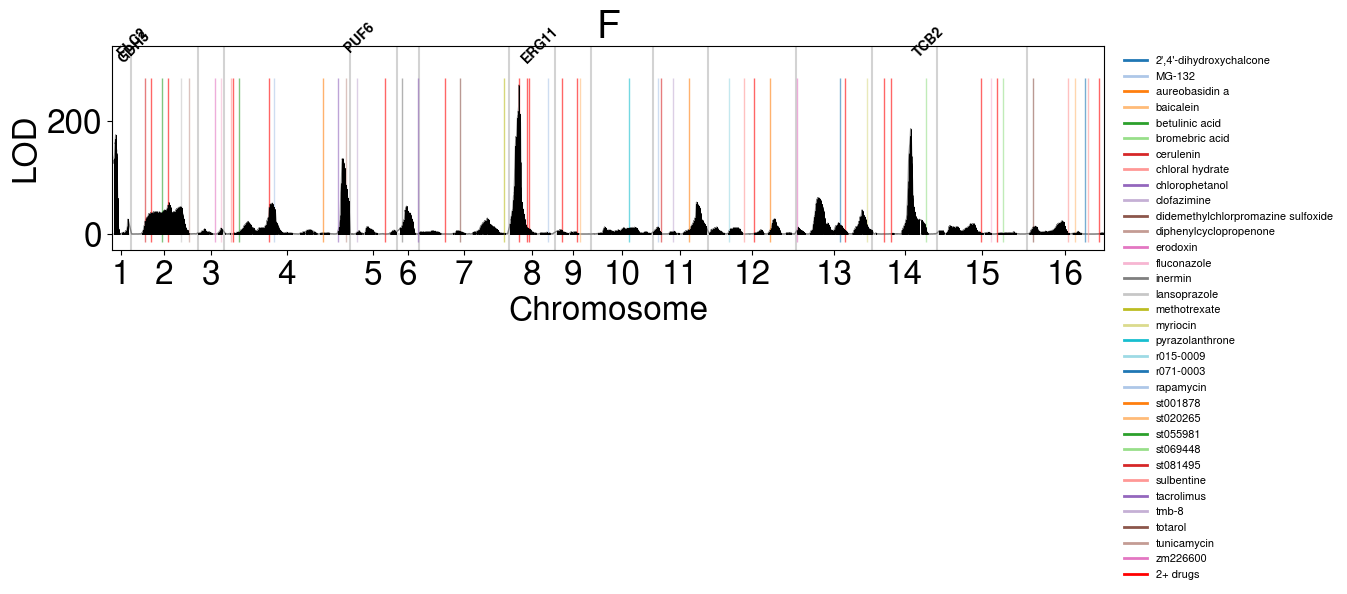

In [11]:
# -------------------------------
# SETTINGS
# -------------------------------
TREATMENT = "F"               # choose one: "C", "H", "F", "D"
QTL_LABEL_LOD_THRESHOLD = 100
MAX_QTL_LABELS = 8
USE_BARS = True              # False = ticks, True = bars
SHOW_DRUG_LEGEND = True

# Build treatment-specific plotting dataframe
df_plot = lod_df[["SNP", "Chromosome", "Position (bp)", "abs_pos", TREATMENT]].copy()
df_plot = df_plot.rename(columns={TREATMENT: "LOD"})

fig, ax = plt.subplots(figsize=(14, 4.8))

# Base Manhattan
make_man(
    df_plot=df_plot,
    ax=ax,
    value="LOD",
    bg_color=pleio_track.reset_index() if pleio_track.index.name == "abs_pos" else pleio_track,
    ylab="LOD"
)

# HIP annotations
if USE_BARS:
    annotate_hip_hits_bars(
        ax,
        hip_hits_df=hip_hits,
        snp_info_df=snp_info,
        show_legend=SHOW_DRUG_LEGEND
    )
else:
    annotate_hip_hits(
        ax,
        hip_hits_df=hip_hits,
        snp_info_df=snp_info,
        show_legend=SHOW_DRUG_LEGEND
    )

# QTL interval labels
annotate_interval_qtl_genes(
    ax,
    qtl_gene_table=qtl_gene_table,
    lod_threshold=QTL_LABEL_LOD_THRESHOLD,
    max_labels=MAX_QTL_LABELS,
    fontsize=10,
    y_offset=6,
    stagger_step=10
)

ax.set_title(f"{TREATMENT}", fontsize=28)

plt.tight_layout()

fig.savefig(
    f"figures/Pulvinatal_LOD_{TREATMENT}_drug_annotated.png",
    format="png",
    bbox_inches="tight"
)

plt.show()